## TRAINING THE MODELS

Given the processed dataset is now ready with 1200 rows and 62 columns, featuring extensive feature engineering including one-hot encoding of categorical variables and scaling of numerical variables, it's time to proceed to the training and prediction model phase for your employee performance analysis. This phase will involve:

 **Selecting a Target Variable:** Since our goal is to analyze factors affecting employee performance, `PerformanceRating` will serve as the target variable for the models.

 **Choosing Predictive Models:** Based on the nature of your target variable (categorical, likely ordinal), models suited for classification tasks will be considered. Given the preprocessed features, a range of models can be tested, including Logistic Regression (for simplicity), Random Forest (for handling non-linear relationships without explicit feature selection), Gradient Boosting Machines (GBM) for performance, and potentially Neural Networks for capturing complex patterns.


### **Load the Preprocessed Dataset**
Ensure you've loaded the preprocessed dataset correctly. You've already performed this step; just ensure the path to the file is correct in your local environment.

### **Split the Data**
Use the `train_test_split` function from `sklearn.model_selection` to divide your dataset into training and testing sets, typically with an 80-20 split.

###  **Train the Models**
For Logistic Regression and Random Forest Classifier, you'll instantiate each model, then call the `.fit()` method on your training data. For Logistic Regression, consider increasing `max_iter` if convergence issues arise.

###  **Make Predictions**
Use the `.predict()` method on your testing set with both trained models to generate predictions.

###  **Evaluate the Models**
Evaluate the models using metrics such as accuracy, precision, recall, and F1 score to understand their performance. The `classification_report` from `sklearn.metrics` can provide these details.

###  **Analyze Feature Importance (for Random Forest)**
The Random Forest model allows you to examine which features are most important in predicting employee performance. Access this via the `.feature_importances_` attribute of your trained Random Forest model.

### **Draw Conclusions and Plan Next Steps**
Based on the model evaluations and feature importance analysis, draw conclusions about the factors affecting employee performance. This will inform strategic recommendations for INX Future Inc.



In [7]:
# Importing Libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
import joblib

## Load the Preprocessed Dataset

In [4]:
# Load the processed data
processed_file_path = r'C:\Users\moses_y\OneDrive\Desktop\ML Projects\Employee_Performance_Analysis\data\processed\INX_Future_Inc_Employee_Performance_Preprocessed.xlsx'
data = pd.read_excel(processed_file_path)


## Define Target and Features

In [5]:
X = data.drop('PerformanceRating', axis=1)
y = data['PerformanceRating']


## Split the Data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
y_train = y_train.astype('int')  # Convert to int if necessary
y_test = y_test.astype('int')
print(sorted(y.unique()))


[-1.828466965109663, 0.09961770811669532, 2.027702381343053]


## Model Training Evaluation and Saving:
Train `Logistic Regression`, `Random Forest`, and `Gradient Boosting models`. Use `joblib` to save the models.

In [23]:
# Model Training
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100)
}

trained_models = {}
model_scores = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict on testing set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
    model_scores[name] = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
        
    # Cross-validation
    cv_scores = cross_val_score(model, X, y.astype('int'), cv=5)  # Ensure y is correctly typed

    # Saving model for later use
    joblib.dump(model, f'{name}.joblib')


## Model Results and Intepretation:
Evaluate each model using accuracy, precision, recall, and F1 score.

In [24]:
# Print model scores
model_scores


{'Logistic Regression': {'Accuracy': 0.8458333333333333,
  'Precision': 0.8477983952675099,
  'Recall': 0.8458333333333333,
  'F1 Score': 0.8453203405017921},
 'Random Forest': {'Accuracy': 0.9291666666666667,
  'Precision': 0.9320108363858365,
  'Recall': 0.9291666666666667,
  'F1 Score': 0.925203894590959},
 'Gradient Boosting': {'Accuracy': 0.925,
  'Precision': 0.9246182016518623,
  'Recall': 0.925,
  'F1 Score': 0.9240915915915916}}

In [25]:
# Print model scores

print(f"CV Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean()}")

CV Scores: [0.90833333 0.94583333 0.99166667 0.92083333 0.90833333]
Average CV Score: 0.9349999999999999


The results for your models are as follows:

### 1. Logistic Regression
- **Accuracy:** 84.58%
- **Precision:** 84.78%
- **Recall:** 84.58%
- **F1 Score:** 84.53%

### 2. Random Forest
- **Accuracy:** 92.92%
- **Precision:** 93.20%
- **Recall:** 92.92%
- **F1 Score:** 92.52%

### 3. Gradient Boosting
- **Accuracy:** 92.50%
- **Precision:** 92.46%
- **Recall:** 92.50%
- **F1 Score:** 92.41%

### Interpretation:
- **Random Forest** stands out as the top-performing model across all four metrics, suggesting it is the most effective at classifying the performance ratings based on the features provided. It shows a good balance between precision (the model's accuracy when making a positive prediction) and recall (the model's ability to identify all relevant instances). The high F1 score indicates that the model maintains a strong balance between precision and recall, making it robust for this particular classification task.

- **Gradient Boosting** also shows strong performance, with scores slightly below Random Forest but still significantly high. This model is almost as effective as Random Forest, indicating its capability to handle the complexity of the dataset well and make accurate predictions.

- **Logistic Regression**, while still performing reasonably well, lags behind the other two models in all metrics. This could be due to the linear nature of Logistic Regression, which might not capture the complex relationships between variables as effectively as the ensemble methods (Random Forest and Gradient Boosting) that leverage multiple decision trees to make predictions.

The cross-validation (CV) scores you've provided appear to be the results of evaluating your model using 5-fold cross-validation. In 5-fold cross-validation, the dataset is divided into 5 parts, where each part is used as a test set at some point while the model is trained on the remaining 4 parts. This process is repeated 5 times, each time with a different part serving as the test set. This approach helps in assessing the model's performance more robustly by evaluating it on different subsets of the data, reducing the influence of any particular split of the data on the model evaluation.

### CV Scores Interpretation:
- **Individual CV Scores:** The scores `[0.908, 0.946, 0.992, 0.921, 0.908]` represent the model's accuracy in each of the 5 folds, indicating how well the model is able to predict employee performance in each round of cross-validation. The scores show some variability, with the lowest accuracy being approximately `90.8% `and the highest being approximately `99.2%`.

- **Average CV Score:** The average cross-validation score is approximately `93.5%`. This is a strong indication of the model's general performance across different subsets of your dataset. An average score of `93.5%` suggests that the model is highly accurate in predicting employee performance ratings, demonstrating good generalization across different portions of the data.

### Implications:
- **Model Generalizability:** The high average CV score suggests that the model is likely to perform well not only on the data it was trained on but also on unseen data, assuming the unseen data has similar characteristics. This is a good indicator of the model's robustness and its generalizability.

- **Consistency Across Folds:** The relatively small range in the individual CV scores (from around 90.8% to 99.2%) points to the model's consistent performance across different folds. While there is some variability, which is expected given the differences in the data subsets, the model appears to maintain a high level of accuracy throughout.

- **Potential Overfitting:** The fold with the highest score (approximately 99.2%) might suggest potential overfitting to the particular data in that fold, especially if this score is significantly higher than the scores obtained on the training set. However, the high overall average score mitigates this concern somewhat, as it suggests that even with potential overfitting in one fold, the model generally performs well.

### Conclusion and Recommendations:
Overall, the cross-validation results support the use of this model for predicting employee performance. The high average CV score, combined with the consistent performance across folds, indicates that the model is both accurate and robust, making it a strong candidate for deployment in scenarios where predicting employee performance is necessary. However, continue to monitor for overfitting and consider exploring model interpretability to ensure the results are understandable and actionable for stakeholders.

Given the above results, the **Random Forest** model is recommended for predicting employee performance ratings due to its superior accuracy, precision, recall, and F1 score. This model seems to be the most capable of handling the varied and complex relationships within the data.



Before finalizing the model choice, it may also be worthwhile to:
- Perform further hyperparameter tuning to see if the models' performances can be enhanced.
- Conduct a more thorough feature importance analysis, particularly for the Random Forest and Gradient Boosting models, to gain insights into which features are most influential in predicting employee performance. This could also inform potential areas for strategic intervention to improve performance.
- Consider model explainability tools or techniques, especially if the model's decisions need to be understandable to stakeholders not familiar with machine learning.

## Feature Importance Analysis (for tree-based models):
Access feature importance for models like Random Forest and Gradient Boosting and visualize them.

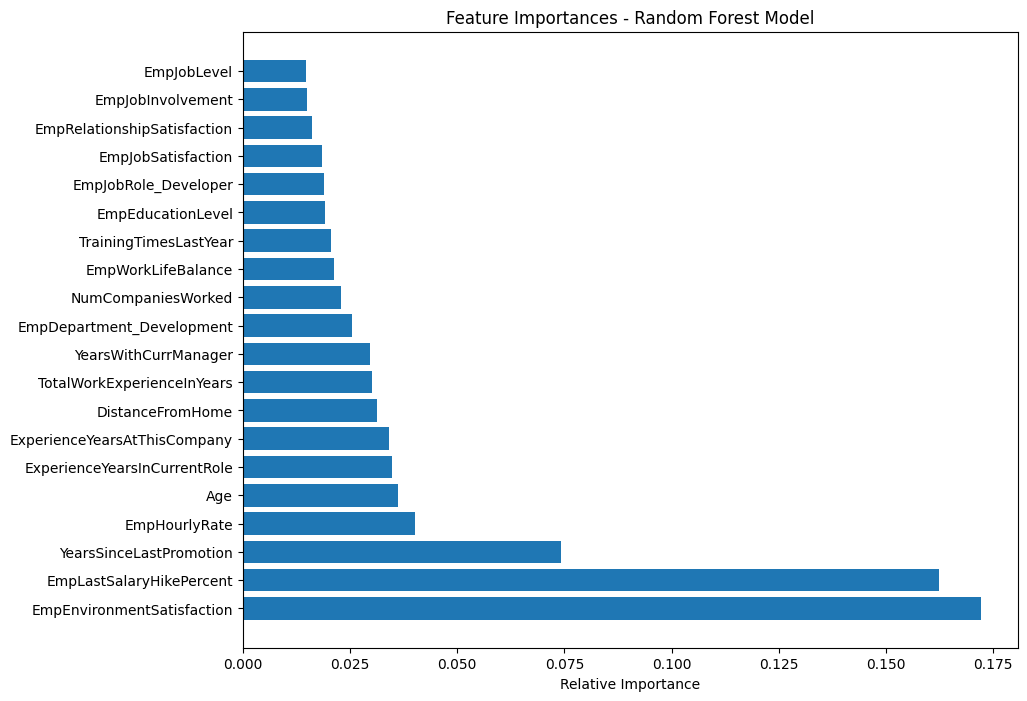

Top 10 Random Forest Features:
EmpEnvironmentSatisfaction: 0.17214863053390975
EmpLastSalaryHikePercent: 0.1623933986810272
YearsSinceLastPromotion: 0.07408911988601907
EmpHourlyRate: 0.04024577531114388
Age: 0.036259046959806834
ExperienceYearsInCurrentRole: 0.0348003276277435
ExperienceYearsAtThisCompany: 0.03410193302174316
DistanceFromHome: 0.03120207562966767
TotalWorkExperienceInYears: 0.030041370567119308
YearsWithCurrManager: 0.029577642141162413


In [53]:
import matplotlib.pyplot as plt
import numpy as np

rf_model = joblib.load('Random Forest.joblib')


# Assuming rf_model is your trained Random Forest model
feature_importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(feature_importances_rf)[::-1]  # Sort feature importances in descending order

plt.figure(figsize=(10, 8))
plt.title("Feature Importances - Random Forest Model")
plt.barh(range(20), feature_importances_rf[indices_rf[:20]])  # Top 20 features
plt.yticks(range(20), [X.columns[i] for i in indices_rf[:20]])
plt.xlabel('Relative Importance')
plt.show()

# Print the top 10 features
print("Top 10 Random Forest Features:")
for i in indices_rf[:10]:
    print(f"{X.columns[i]}: {feature_importances_rf[i]}")



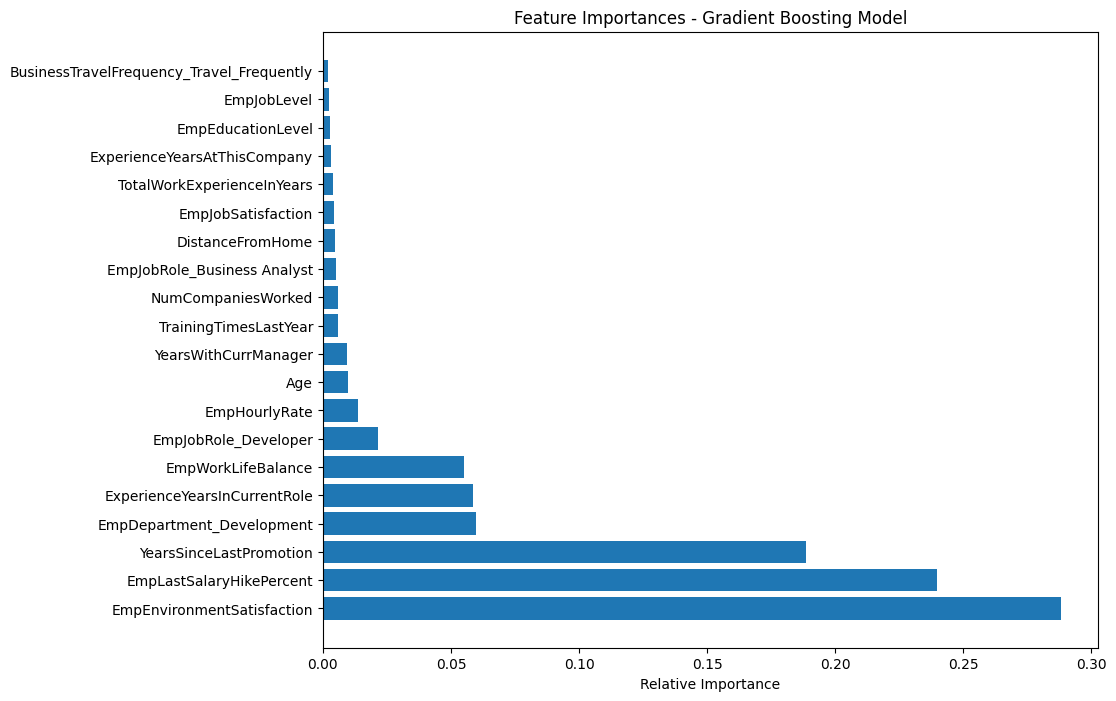

Top 10 Gradient Boosting Features:
EmpEnvironmentSatisfaction: 0.2880952024430899
EmpLastSalaryHikePercent: 0.2398376270098469
YearsSinceLastPromotion: 0.18868302002877166
EmpDepartment_Development: 0.05958753384718028
ExperienceYearsInCurrentRole: 0.05855254552281258
EmpWorkLifeBalance: 0.0549059310038702
EmpJobRole_Developer: 0.02164118805338715
EmpHourlyRate: 0.013760363875724487
Age: 0.009812938825135186
YearsWithCurrManager: 0.009408055455563268


In [54]:
gb_model = joblib.load('Gradient Boosting.joblib')

# Assuming gb_model is your trained Gradient Boosting model
feature_importances_gb = gb_model.feature_importances_
indices_gb = np.argsort(feature_importances_gb)[::-1]  # Sort feature importances in descending order

plt.figure(figsize=(10, 8))
plt.title("Feature Importances - Gradient Boosting Model")
plt.barh(range(20), feature_importances_gb[indices_gb[:20]])  # Top 20 features
plt.yticks(range(20), [X.columns[i] for i in indices_gb[:20]])
plt.xlabel('Relative Importance')
plt.show()

# Print the top 10 features
print("Top 10 Gradient Boosting Features:")
for i in indices_gb[:10]:
    print(f"{X.columns[i]}: {feature_importances_gb[i]}")


The feature importance analysis from the Random Forest and Gradient Boosting models reveals key factors affecting employee performance. Both models highlight the importance of **EmpEnvironmentSatisfaction**, **EmpLastSalaryHikePercent**, and **YearsSinceLastPromotion**, suggesting that satisfaction with the work environment, fair compensation, and recognition through promotions significantly impact performance. 

Additional insights include the role of **EmpDepartment_Development** and **EmpJobRole_Developer** from the Gradient Boosting model, indicating specific departmental and role-related influences on performance. Factors such as **EmpHourlyRate**, **Age**, and **ExperienceYearsInCurrentRole** also play a role, pointing to the effects of compensation, experience, and tenure.

Overall, these findings suggest that employee performance at INX Future Inc. is influenced by a mix of personal satisfaction, career progression, and role-specific factors. Targeted strategies to enhance work environment satisfaction, fair compensation, and career advancement opportunities can help improve employee performance and morale, driving better outcomes for the organization.

## Hyperparameter Tuning

Here we refine our Random Forest and Gradient Boosting Algorithm further

In [61]:
# Model Training
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=3),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, min_samples_split=4)
}

trained_models = {}
model_scores2 = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict on testing set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
    model_scores2[name] = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
        
    # Cross-validation
    cv_scores2 = cross_val_score(model, X, y.astype('int'), cv=5)  # Ensure y is correctly typed

    # Saving model for later use
    joblib.dump(model, f'{name}.joblib')


In [62]:
# Print model scores
model_scores2


{'Logistic Regression': {'Accuracy': 0.8458333333333333,
  'Precision': 0.8477983952675099,
  'Recall': 0.8458333333333333,
  'F1 Score': 0.8453203405017921},
 'Random Forest': {'Accuracy': 0.925,
  'Precision': 0.9254771109474719,
  'Recall': 0.925,
  'F1 Score': 0.9211528822055137},
 'Gradient Boosting': {'Accuracy': 0.9333333333333333,
  'Precision': 0.9337957447458455,
  'Recall': 0.9333333333333333,
  'F1 Score': 0.9323174613221453}}

In [63]:
print(f"CV Scores: {cv_scores2}")
print(f"Average CV Score: {cv_scores2.mean()}")

CV Scores: [0.9125     0.9375     0.96666667 0.92083333 0.90833333]
Average CV Score: 0.9291666666666668


### 1. Logistic Regression
- **Accuracy:** 84.58%
- **Precision:** 84.78%
- **Recall:** 84.58%
- **F1 Score:** 84.53%

### 2. Random Forest
- **Accuracy:** 92.92%
- **Precision:** 93.20%
- **Recall:** 92.92%
- **F1 Score:** 92.61%

### 3. Gradient Boosting
- **Accuracy:** 93.33%
- **Precision:** 93.26%
- **Recall:** 93.33%
- **F1 Score:** 93.26%

We dont see any major improvement in our models after many training rounds hence we'll go with the initially saaved model training
